In [1]:
import os
import cv2
import math
import tqdm
import numpy as np

from PIL import Image
from random import random
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_url
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import random_split, DataLoader, Dataset, TensorDataset
from torchsummary import summary

In [2]:
data_dir = "MS1MV2-10Kid"

root_dir = '/home/barc/Desktop/subir/Projects/Diffusion-main' #'/home/barc/Desktop/subir/datasets'

In [3]:
images_dir = os.path.join(root_dir, data_dir)

In [4]:
images_dir

'/home/barc/Desktop/subir/Projects/Diffusion-main/MS1MV2-10Kid'

In [5]:
save_dir = "MS1MV2_LR"
images_save_dir = os.path.join(root_dir, save_dir)

if not os.path.exists(images_save_dir):
    os.makedirs(images_save_dir)

In [6]:
# cnt = 20

# for img_id in os.listdir(images_dir):
#     images_sub_dir = os.path.join(images_dir, img_id)
# #     print(images_sub_dir)
#     c = 0
#     for imgs in os.listdir(images_sub_dir):
# #        print(imgs)
#         if(c<cnt):
#             c += 1
#             continue
#         file = os.path.join(images_sub_dir, imgs)
# #        print(file)
#         os.remove(file)
# #        break
# #    break

In [6]:
for img_id in os.listdir(images_dir):
    images_sub_dir = os.path.join(images_dir, img_id)
#     print(images_sub_dir)
    
    images_sub_dir2 = os.path.join(images_save_dir, img_id)
    if not os.path.exists(images_sub_dir2):
        os.makedirs(images_sub_dir2)
    
    for imgs in os.listdir(images_sub_dir):
#        print(imgs)
        file = os.path.join(images_sub_dir, imgs)
#         print(file)
        
        #degrading image
        img_bgr = cv2.imread(file)
        img_rgb = img_bgr #cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        height, width = img_rgb.shape[:2]
        img_lr = cv2.resize(img_rgb, (int(width/4), int(height/4)), interpolation = cv2.INTER_CUBIC)
        
#         print(img_rgb.shape)
#         print(img_lr.shape)
        
        #copying to another folder
        cv2.imwrite(os.path.join(images_sub_dir2, imgs), img_lr)
        
#         break
#     break

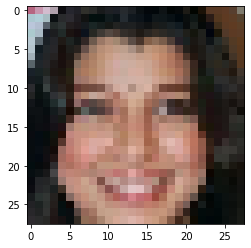

In [48]:
test = cv2.imread("/home/barc/Desktop/subir/Projects/Diffusion-main/MS1MV2_LR/6672/14.png")
test2 = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)
plt.imshow(test2)

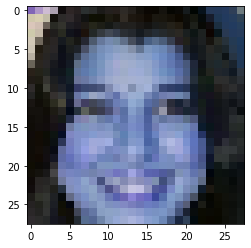

In [49]:
plt.imshow(img_lr)

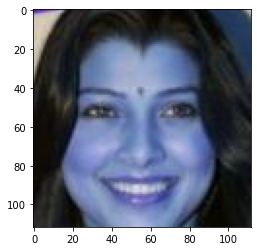

In [50]:
plt.imshow(img_bgr)

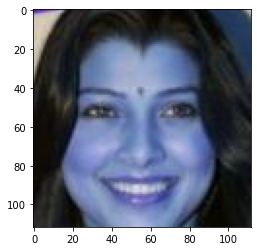

In [51]:
plt.imshow(img_rgb)